DETECTIING WHETHER A GIVEN MESSAGE IS SPAM OR NOT

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import nltk
from nltk.stem.porter import PorterStemmer
import pickle

In [ ]:
df = pd.read_csv("/content/spam.csv", encoding="latin-1")

In [ ]:
print(df.shape)
df.sample(5)

(5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
674,ham,"I've got &lt;#&gt; , any way I could pick up?",NaN,NaN,NaN
3741,ham,Hey i'm bored... So i'm thinking of u... So wa...,NaN,NaN,NaN
1280,ham,Oh ho. Is this the first time u use these type...,NaN,NaN,NaN
4186,ham,Dear got bus directly to calicut,NaN,NaN,NaN
4557,ham,PISS IS TALKING IS SOMEONE THAT REALISE U THAT...,NaN,NaN,NaN


In [ ]:
# for col in df.columns:
#     print(df[col], " :", df[col].isnull().value_counts())
dt = df.columns
print(dt)
for col in dt:
    print(col, ": " , df[col].isnull().value_counts())

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')
v1 :  v1
False    5572
Name: count, dtype: int64
v2 :  v2
False    5572
Name: count, dtype: int64
Unnamed: 2 :  Unnamed: 2
True     5522
False      50
Name: count, dtype: int64
Unnamed: 3 :  Unnamed: 3
True     5560
False      12
Name: count, dtype: int64
Unnamed: 4 :  Unnamed: 4
True     5566
False       6
Name: count, dtype: int64


In [ ]:
df['status'] = df['v1']
df = df.drop(['v1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df.sample(3)

,v2,status
3336,I AM AT THE GAS STATION. GO THERE.,ham
3070,Apart from the one i told you about yesterday?,ham
1285,"Just wondering, the others just took off",ham


In [ ]:
print(df.duplicated().sum())
df = df.drop_duplicates(keep='first')
df.shape

403


(5169, 2)

In [ ]:
df['status'].value_counts()

,count
status,
ham,4516
spam,653


In [ ]:
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()
print(df.head(3))
df['status'] = encode.fit_transform(df['status'])
print(df.head(3))


                                                  v2 status
0  Go until jurong point, crazy.. Available only ...    ham
1                      Ok lar... Joking wif u oni...    ham
2  Free entry in 2 a wkly comp to win FA Cup fina...   spam
                                                  v2  status
0  Go until jurong point, crazy.. Available only ...       0
1                      Ok lar... Joking wif u oni...       0
2  Free entry in 2 a wkly comp to win FA Cup fina...       1


WE CAN'T MARK HAM TO SPAM (IT'S OK TO CONSIDER SPAM AS HAM, BUT A HAM MESSAGE SHOULDN'T BE CONSIDERED AS SPAM)


In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
df.head(4)

,v2,status
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0


In [ ]:
df['num_char'] = df['v2'].apply(lambda x : len(x))
df['num_word'] = df['v2'].apply(lambda x : len(nltk.word_tokenize(x)))

In [ ]:
df.sample(5)

,v2,status,num_char,num_word
3906,No that just means you have a fat head,0,38,9
5231,I realise you are a busy guy and i'm trying no...,0,143,37
3514,I'm job profile seems like bpo..,0,32,8
3068,Ay wana meet on sat?Ì_ wkg on sat?,0,34,11
5106,Ding me on ya break fassyole! Blacko from londn,0,47,10


In [ ]:
df[df['status'] == 1].describe()

,status,num_char,num_word
count,653.0,653.000000,653.000000
mean,1.0,137.891271,27.667688
std,0.0,30.137753,7.008418
min,1.0,13.000000,2.000000
25%,1.0,132.000000,25.000000
50%,1.0,149.000000,29.000000
75%,1.0,157.000000,32.000000
max,1.0,224.000000,46.000000


In [ ]:
df[df['status'] == 0].describe()

,status,num_char,num_word
count,4516.0,4516.000000,4516.000000
mean,0.0,70.459256,17.123782
std,0.0,56.358207,13.493970
min,0.0,2.000000,1.000000
25%,0.0,34.000000,8.000000
50%,0.0,52.000000,13.000000
75%,0.0,90.000000,22.000000
max,0.0,910.000000,220.000000


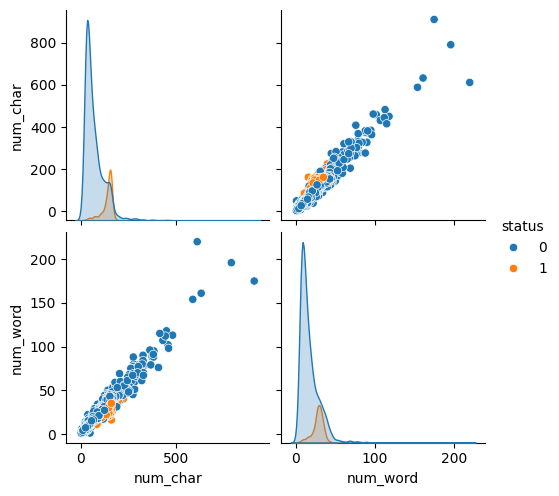

In [ ]:
sns.pairplot(df, hue='status')

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
ps = PorterStemmer()

In [ ]:
from string import punctuation
from nltk.corpus import stopwords
def convert(text):
    text = text.lower()
    x = nltk.word_tokenize(text)

    #keep alpha nuberic characters only
    res = []
    for let in x:
        if let.isalnum():
            res.append(let)

    res2 = res[:]
    res.clear()
    for let in res2:
        if let not in punctuation and let not in stopwords.words('english'):
            res.append(let)


    res2 = res[:]
    res.clear()

    for let in res2:
        res.append(ps.stem(let))


    return " ".join(res)

def convert2(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))


    return " ".join(y)

In [ ]:
print(convert("Hey someeran !!! how re you... 2bhai let's grab some drink and learn machine learning"))
convert2("Hey someeran !!! how re you... 2bhai let's grab some drink and learn machine learning")

hey someeran 2bhai let grab drink learn machin learn


'hey someeran 2bhai let grab drink learn machin learn'

In [ ]:
dt = df[['status', 'num_char', 'num_word']]
dt.corr()


,status,num_char,num_word
status,1.000000,0.384717,0.262912
num_char,0.384717,1.000000,0.965760
num_word,0.262912,0.965760,1.000000


In [ ]:
df['text'] = df['v2'].apply(convert2)

In [ ]:

df.head(5)

,v2,status,num_char,num_word,text
0,"Go until jurong point, crazy.. Available only ...",0,111,24,go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,0,29,8,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,0,49,13,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",0,61,15,nah think goe usf live around though


In [ ]:
df['num_char'] = df['text'].apply(lambda x : len(x))

In [ ]:
df.head(5)

,v2,status,num_char,num_word,text
0,"Go until jurong point, crazy.. Available only ...",0,76,24,go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,0,21,8,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,127,37,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,0,35,13,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",0,36,15,nah think goe usf live around though


In [ ]:
df.drop(['num_word'], axis = 1)


,v2,status,num_char,text
0,"Go until jurong point, crazy.. Available only ...",0,76,go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,0,21,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,127,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,0,35,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",0,36,nah think goe usf live around though
...,...,...,...,...
5567,This is the 2nd time we have tried 2 contact u...,1,86,2nd time tri 2 contact u pound prize 2 claim e...
5568,Will Ì_ b going to esplanade fr home?,0,21,b go esplanad fr home
5569,"Pity, * was in mood for that. So...any other s...",0,17,piti mood suggest
5570,The guy did some bitching but I acted like i'd...,0,65,guy bitch act like interest buy someth els nex...


In [ ]:
df['status'].value_counts()

,count
status,
0,4516
1,653


<Axes: >

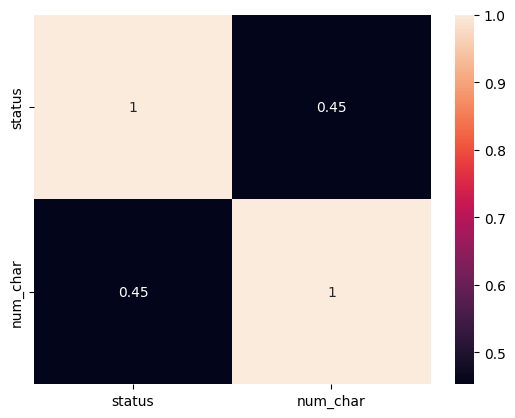

In [ ]:
sns.heatmap(df[['status', 'num_char']].corr(), annot=True)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfdf = TfidfVectorizer(max_features=3000)

dat = "hey its me someeran how you are doing"
dat = dat.split()
x = cv.fit_transform(dat)
x.toarray()



array([[0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0]])

In [ ]:
df.shape

(5169, 5)

FINDING THE MOST OCCURING WORD IN SPAM

In [ ]:
data = df[df['status'] == 1]['text'].tolist()
print("done")

done


In [ ]:
spam = []
for sent in data:
  for word in sent.split():
    spam.append(word)

print(len(spam))


9939


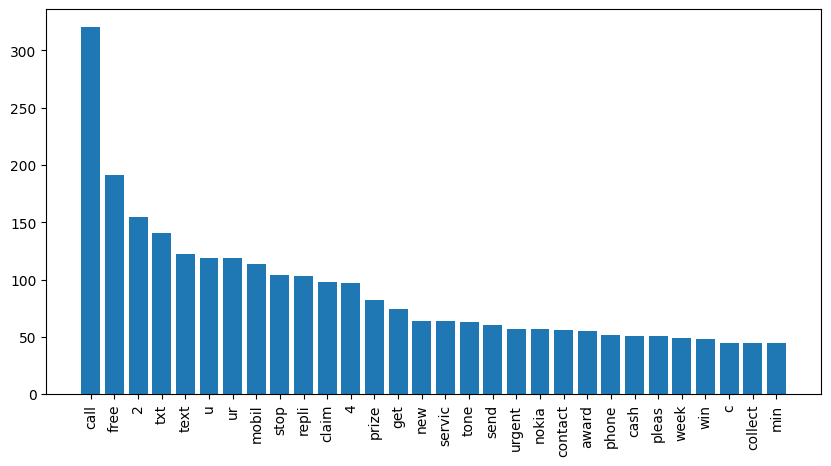

In [ ]:

from collections import Counter
data = Counter(spam).most_common(30)
data = pd.DataFrame(data, columns=['word', 'count'])
plt.figure(figsize=(10, 5))
plt.bar(data['word'], data['count'])
plt.xticks(rotation=90)
plt.show()

35404


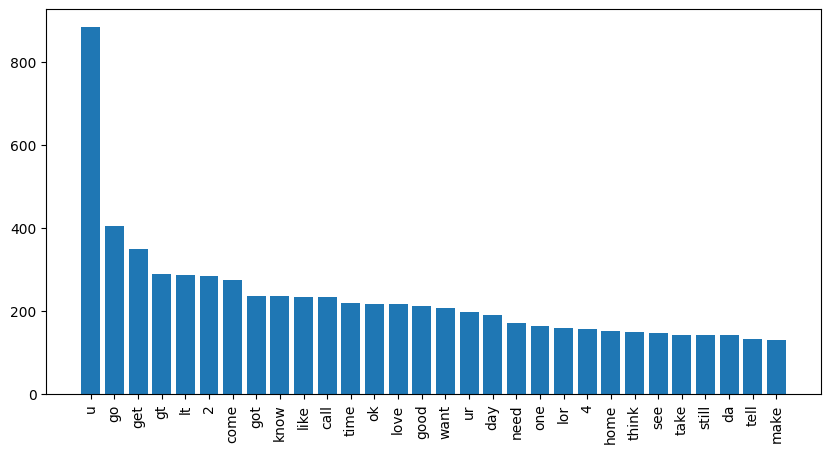

In [ ]:
ham = []
for sent in df[df['status'] == 0]['text']:
  for word in sent.split():
    ham.append(word)

print(len(ham))

data = Counter(ham).most_common(30)
data = pd.DataFrame(data, columns=['word', 'count'])
plt.figure(figsize=(10, 5))
plt.bar(data['word'], data['count'])
plt.xticks(rotation=90)
plt.show()

**BUILDING MODEL**


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfdf = TfidfVectorizer(max_features=3000)

x = cv.fit_transform(df['text']).toarray()
pickle.dump(cv, open('vectorizer.pkl', 'wb'))
x1 = tfdf.fit_transform(df['text']).toarray()
y = df['status'].values
print(x, x1, y)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]] [0 0 1 ... 0 0 0]


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y, test_size = 0.2, random_state = 42)
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier


mnb = MultinomialNB()
gnb = GaussianNB()
bnb = BernoulliNB()


mnb.fit(x_train, y_train)
gnb.fit(x_train, y_train)
bnb.fit(x_train, y_train)

dict = {"mnb" : mnb, "gnb" : gnb, "bnb" : bnb}


**HERE PRECISION MATTERS MORE- WE CAN'T SAY A HAM MESSAGE IS A SPAM**

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score
for key in dict:
  print(key, " ")
  y_pred = dict.get(key).predict(x_test)
  # print(classification_report(y_test, y_pred))
  print(confusion_matrix(y_test, y_pred))
  print(accuracy_score(y_test, y_pred))

mnb  
[[872  17]
 [ 10 135]]
0.9738878143133463
gnb  
[[772 117]
 [ 19 126]]
0.8684719535783365
bnb  
[[885   4]
 [ 31 114]]
0.9661508704061895


In [ ]:
mnb = MultinomialNB()
gnb = GaussianNB()
bnb = BernoulliNB()


mnb.fit(x1_train, y1_train)
gnb.fit(x1_train, y1_train)
bnb.fit(x1_train, y1_train)

dict = {"mnb" : mnb, "gnb" : gnb, "bnb" : bnb}


from sklearn.metrics import classification_report, accuracy_score
for key in dict:
  print(key, " ")
  y_pred = dict.get(key).predict(x1_test)
  #print(classification_report(y1_test, y_pred))
  print(confusion_matrix(y1_test, y_pred))
  print(accuracy_score(y1_test, y_pred))

mnb  
[[888   1]
 [ 27 118]]
0.9729206963249516
gnb  
[[771 118]
 [ 24 121]]
0.8626692456479691
bnb  
[[884   5]
 [ 23 122]]
0.9729206963249516


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)


clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'GBDT':gbdt,
    'xgb':xgb
}



In [ ]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision
accuracy_scores = []
precision_scores = []



for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, x_train,y_train,x_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9323017408123792
Precision -  0.7737226277372263
For  KN
Accuracy -  0.9042553191489362
Precision -  1.0
For  NB
Accuracy -  0.9738878143133463
Precision -  0.8881578947368421
For  DT
Accuracy -  0.9235976789168279
Precision -  0.9230769230769231
For  LR
Accuracy -  0.9709864603481625
Precision -  0.9457364341085271
For  RF
Accuracy -  0.9671179883945842
Precision -  1.0
For  AdaBoost
Accuracy -  0.90715667311412
Precision -  0.8656716417910447
For  GBDT
Accuracy -  0.9342359767891683
Precision -  0.8811881188118812
For  xgb
Accuracy -  0.9700193423597679
Precision -  0.9453125


In [ ]:
# def train_classifier(clf,X_train,y_train,X_test,y_test):
#     clf.fit(X_train,y_train)
#     y_pred = clf.predict(X_test)
#     accuracy = accuracy_score(y_test,y_pred)
#     precision = precision_score(y_test,y_pred)

#     return accuracy,precision
# accuracy_scores = []
# precision_scores = []



# for name,clf in clfs.items():

#     current_accuracy,current_precision = train_classifier(clf, x1_train,y1_train,x1_test,y1_test)

#     print("For ",name)
#     print("Accuracy - ",current_accuracy)
#     print("Precision - ",current_precision)

#     accuracy_scores.append(current_accuracy)
#     precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9477611940298507
For  KN
Accuracy -  0.90715667311412
Precision -  1.0
For  NB
Accuracy -  0.9729206963249516
Precision -  0.9915966386554622
For  DT
Accuracy -  0.9313346228239845
Precision -  0.8135593220338984
For  LR
Accuracy -  0.9468085106382979
Precision -  0.8629032258064516
For  RF
Accuracy -  0.971953578336557
Precision -  0.9915254237288136
For  AdaBoost
Accuracy -  0.913926499032882
Precision -  0.7916666666666666
For  GBDT
Accuracy -  0.9497098646034816
Precision -  0.9514563106796117
For  xgb
Accuracy -  0.9661508704061895
Precision -  0.9230769230769231


**RANDOM FOREST IS OUTPERFORMING WITH PRECISOIN 100% COMPARED TO OTHER ALGORITHMS **

In [ ]:
def do_train(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return clf, accuracy,precision

rfc = RandomForestClassifier(n_estimators=50, random_state=2)
rfc, current_accuracy,current_precision = do_train(rfc, x_train,y_train,x_test,y_test)
print("Accuracy - ",current_accuracy)
print("Precision - ",current_precision)

Accuracy -  0.9671179883945842
Precision -  1.0


In [ ]:
y_pred = rfc.predict(x_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       1.00      0.77      0.87       145

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034

[[889   0]
 [ 34 111]]


In [ ]:
x_test

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
print(len(y_train))
print("zeroes : ", len(y_train) - np.count_nonzero(y_train), "ones : ", np.count_nonzero(y_train))


4135
zeroes :  3627 ones :  508


In [ ]:

print(rfc.n_features_in_)

6708


TASK TO DO WHEN WE GET A SMS TO VERIFY
1. DO STEMING AND CHANGE THE FORMAT OF TEXT
2. VECTORIZED THAT USING TFIDF
3. PREDICT USING MODEL

REQUIREMENT:
1. MODEL
2. PORTSCANNER
3. VECTORIZER

In [ ]:
import pickle
pickle.dump(rfc, open('model.pkl', 'wb'))
pickle.dump(ps, open('stemmer.pkl', 'wb'))


EXTRACTING RANDOM SAMPLE DATA FOR TESTING OF MODEL (5-5 SPAM AND HAM )

In [ ]:
import random
random_data = {}
# for i in range(5):
#   random_data.append(random.choice(df[df['status'] == 0]['text']))

# for i in range(5):
#   random_data.append(random.choice(df[df['status'] == 1]['text']))
data = df[df['status'] == 1]['v2'].sample(5)
for i in data:
  random_data[i] = 1

data = df[df['status'] == 0]['v2'].sample(5)
for i in data:
  random_data[i] = 0

print(random_data)

{'PRIVATE! Your 2003 Account Statement for 07815296484 shows 800 un-redeemed S.I.M. points. Call 08718738001 Identifier Code 41782 Expires 18/11/04 ': 1, 'FREE MSG:We billed your mobile number by mistake from shortcode 83332.Please call 08081263000 to have charges refunded.This call will be free from a BT landline': 1, 'No. 1 Nokia Tone 4 ur mob every week! Just txt NOK to 87021. 1st Tone FREE ! so get txtin now and tell ur friends. 150p/tone. 16 reply HL 4info': 1, 'HOT LIVE FANTASIES call now 08707509020 Just 20p per min NTT Ltd, PO Box 1327 Croydon CR9 5WB 0870..k': 1, 'Got what it takes 2 take part in the WRC Rally in Oz? U can with Lucozade Energy! Text RALLY LE to 61200 (25p), see packs or lucozade.co.uk/wrc & itcould be u!': 1, 'Send his number and give reply tomorrow morning for why you said that to him like that ok': 0, "K, jason says he's gonna be around so I'll be up there around  &lt;#&gt;": 0, 'I can make lasagna for you... vodka...': 0, 'Take us out shopping and Mark will

In [ ]:
# from sklearn.tree import plot_tree
# rfc.feature_importances_
# chosen_tree = rfc.estimators_[0]


# plt.figure(figsize=(15, 8))
# plot_tree(
#     chosen_tree,
#     filled=True,
#     rounded=True,
#     fontsize=10
# )
# plt.title("Visual Structure of Tree #0 in the Random Forest")
# plt.show()